Enter your CO₂-related query:  car



Detected Category: Transport
Relevant Activity Example: Car (Petrol, 20 km)
Avg CO₂ Emission: 4.6 kg/day

Suggested Actions:
1. Use public transport or carpooling to reduce emissions.
2. Try cycling or walking for short distances.
3. Consider switching to electric or hybrid vehicles.


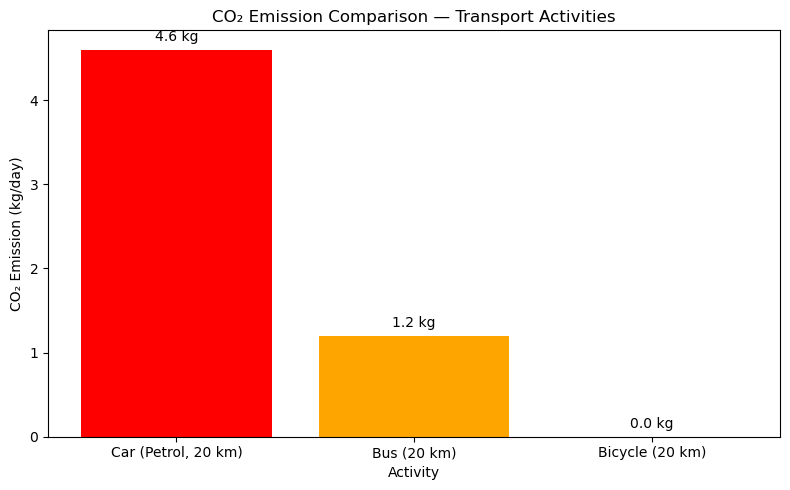


Summary:
- Reduce car usage, consider public transport or cycling.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from difflib import get_close_matches

# Dataset
data = {
    'Activity': ['Car (Petrol, 20 km)', 'Bus (20 km)', 'Bicycle (20 km)', 'AC usage (8 hrs/day)',
                 'LED Bulb (5 hrs/day)', 'Old Bulb (5 hrs/day)', 'Meat-based diet', 'Vegetarian diet',
                 'Online shopping (1)', 'Local shopping (1)'],
    'Avg_CO2_Emission(kg/day)': [4.6, 1.2, 0.0, 6.0, 0.05, 0.2, 7.0, 2.0, 1.0, 0.3],
    'Category': ['Transport', 'Transport', 'Transport', 'Household', 'Household', 'Household', 'Food', 'Food', 'Lifestyle', 'Lifestyle']
}

df = pd.DataFrame(data)

# Tips
tips = {
    'Transport': [
        'Use public transport or carpooling to reduce emissions.',
        'Try cycling or walking for short distances.',
        'Consider switching to electric or hybrid vehicles.'
    ],
    'Household': [
        'Use LED bulbs and energy-efficient appliances.',
        'Turn off AC when not needed and maintain 24°C temperature.',
        'Unplug devices when not in use.'
    ],
    'Food': [
        'Try reducing meat consumption.',
        'Include more plant-based meals.',
        'Avoid food waste by portioning wisely.'
    ],
    'Lifestyle': [
        'Prefer local shopping to minimize transport emissions.',
        'Avoid unnecessary online orders.',
        'Buy durable products to reduce waste.'
    ]
}

# Keywords for generative mapping
keywords = {
    'Transport': ['car', 'drive', 'bus', 'bike', 'bicycle', 'scooter', 'commute', 'transport'],
    'Household': ['ac', 'air conditioner', 'bulb', 'fridge', 'appliance', 'home', 'electricity'],
    'Food': ['diet', 'meal', 'vegetarian', 'meat', 'vegan', 'food', 'eat', 'consume'],
    'Lifestyle': ['shopping', 'order', 'lifestyle', 'online', 'buy', 'clothes', 'fashion']
}

def detect_category(query):
    query_lower = query.lower()
    scores = {}
    for cat, words in keywords.items():
        scores[cat] = sum(word in query_lower for word in words)
    # pick category with highest match
    category = max(scores, key=scores.get)
    if scores[category] == 0:
        category = 'Lifestyle'  # default
    return category

def suggest_activity(query, category):
    # Try fuzzy matching activity names
    activities = df[df['Category'] == category]['Activity'].tolist()
    match = get_close_matches(query, activities, n=1, cutoff=0.2)
    return match[0] if match else activities[0]

def plot_emission(category):
    cat_df = df[df['Category'] == category]
    labels = cat_df['Activity'].tolist()
    values = cat_df['Avg_CO2_Emission(kg/day)'].tolist()
    colors = ['red' if v > 3 else 'orange' if v > 1 else 'green' for v in values]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=colors)
    plt.title(f'CO₂ Emission Comparison — {category} Activities')
    plt.xlabel('Activity')
    plt.ylabel('CO₂ Emission (kg/day)')
    for i, v in enumerate(values):
        plt.text(i, v + 0.1, f"{v} kg", ha='center')
    plt.tight_layout()
    plt.show()

# ------------------ Main Generative Flow ------------------ #
query = input("Enter your CO₂-related query: ")

category = detect_category(query)
activity = suggest_activity(query, category)
avg_co2 = df[df['Activity'] == activity]['Avg_CO2_Emission(kg/day)'].values[0]

print(f"\nDetected Category: {category}")
print(f"Relevant Activity Example: {activity}")
print(f"Avg CO₂ Emission: {avg_co2} kg/day")

print("\nSuggested Actions:")
for i, tip in enumerate(tips[category], 1):
    print(f"{i}. {tip}")

# Plot
plot_emission(category)

# Summary
print("\nSummary:")
if category == 'Transport':
    print("- Reduce car usage, consider public transport or cycling.")
elif category == 'Household':
    print("- Reduce electricity use, prefer energy-efficient appliances.")
elif category == 'Food':
    print("- Reduce meat consumption and food waste.")
else:
    print("- Shop locally and avoid unnecessary purchases.")
